**To view and run this file on google colab:** [https://colab.research.google.com/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb](https://colab.research.google.com/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb)


In [241]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import ticker


# **1. Data loading and understanding**


### **1.1 Load each dataset and display its structure**


In [242]:
def load_excel_file(sheet_name):
    # using remote url as fallback so it even runs on external environments like google collab
    local_excel_file_path = (
        "../data/raw/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"
    )
    remote_excel_file_path = "https://raw.githubusercontent.com/chetanchandel31/da_phone_pe/main/data/raw/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"
    try:
        return pd.read_excel(local_excel_file_path, sheet_name=sheet_name)
    except FileNotFoundError:
        return pd.read_excel(remote_excel_file_path, sheet_name=sheet_name, engine="openpyxl")
    except Exception as e:
        print("unexpected error while loading data", e)
        raise


dfs = {
    "state_txn_users": load_excel_file(sheet_name="State_Txn and Users"),
    "district_txn_users": load_excel_file(sheet_name="District_Txn and Users"),
    "state_txn_type_split": load_excel_file(sheet_name="State_TxnSplit"),
    "state_device_data": load_excel_file(sheet_name="State_DeviceData"),
    "district_demographics": load_excel_file(sheet_name="District Demographics"),
}


### 1.1.1 Load the `State_Txn and Users` dataset and display its first 5 rows.


In [243]:
dfs["state_txn_users"].head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


### 1.1.2 Load the `State_TxnSplit` dataset and display its bottom 10 rows.


In [244]:
dfs["state_txn_type_split"].tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


### 1.1.3 Load the `State_DeviceData` dataset and display 10 rows from the middle of the dataset.


In [245]:
num_rows = dfs["state_device_data"].shape[0]
start_idx = round(num_rows / 2) - 5
end_idx = start_idx + 10
dfs["state_device_data"].iloc[start_idx:end_idx, :]


,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


### 1.1.4 Load the `District_Txn and Users` dataset and display its first 10 rows and last 10 rows.


In [246]:
print("First 10 rows:")
display(dfs["district_txn_users"].head(10))

print()

print("Last 10 rows:")
display(dfs["district_txn_users"].tail(10))

First 10 rows:


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0



Last 10 rows:


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


### 1.1.5 Load the `District Demographics` dataset and display every 10th row.


In [247]:
dfs["district_demographics"][::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


### **1.2 Display basic statistics and data types for each dataset**


### 1.2.1 For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.


In [248]:
display(Markdown("**State Txn and Users:**"))
display(dfs["state_txn_users"].describe())

display(Markdown("**District Txn and Users:**"))
display(dfs["district_txn_users"].describe())

display(Markdown("**State Txn Type Split:**"))
display(dfs["state_txn_type_split"].describe())

display(Markdown("**State Device Data:**"))
display(dfs["state_device_data"].describe())

display(Markdown("**District Demographics:**"))
display(dfs["district_demographics"].describe())

**State Txn and Users:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


**District Txn and Users:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


**State Txn Type Split:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


**State Device Data:**

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


**District Demographics:**

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


### 1.2.2 Display the data types of each column in each dataset.


In [249]:
display(Markdown("**State Txn and Users:**"))
display(dfs["state_txn_users"].dtypes)

display(Markdown("**District Txn and Users:**"))
display(dfs["district_txn_users"].dtypes)

display(Markdown("**State Txn Type Split:**"))
display(dfs["state_txn_type_split"].dtypes)

display(Markdown("**State Device Data:**"))
display(dfs["state_device_data"].dtypes)

display(Markdown("**District Demographics:**"))
display(dfs["district_demographics"].dtypes)

**State Txn and Users:**

State                   str
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

**District Txn and Users:**

State                   str
Year                  int64
Quarter               int64
District                str
Code                    str
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

**State Txn Type Split:**

State                   str
Year                  int64
Quarter               int64
Transaction Type        str
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

**State Device Data:**

State                   str
Year                  int64
Quarter               int64
Brand                   str
Registered Users      int64
Percentage          float64
dtype: object

**District Demographics:**

State                 str
District              str
Headquarters          str
Population          int64
Area (sq km)      float64
Density             int64
Code                  str
Alternate Name        str
dtype: object

### **1.3 Check for missing values**


### 1.3.1 Identify any missing values in each dataset.


In [250]:
for df_name, df in dfs.items():
    display(Markdown(f"#### **For {df_name}:**"))

    display(Markdown("**Columns with null values**"))
    df_cols_to_nan_count = df.isna().sum()
    display(df_cols_to_nan_count[df_cols_to_nan_count > 0])

    display(Markdown("**Numeric columns with 0s**"))
    df_num_cols_to_zero_count = (df.select_dtypes(include="number") == 0).sum()
    display(df_num_cols_to_zero_count[df_num_cols_to_zero_count > 0])

    display(Markdown("---"))

#### **For state_txn_users:**

**Columns with null values**

Amount (INR)    1
dtype: int64

**Numeric columns with 0s**

ATV (INR)      1
App Opens    180
dtype: int64

...

**Columns with null values**

Series([], dtype: int64)

**Numeric columns with 0s**

Population      14
Area (sq km)    15
Density         18
dtype: int64

---

For each sheet, we will investigate in the upcoming sections whether the `0`s represent genuine zero values or are being used as placeholders for missing values, and whether the actual `null` values should be imputed, dropped, or retained.


### 1.3.2 Calculate the percentage of missing values for each column that has missing values.
and
### 1.3.3 Highlight which column has the highest percentage of missing values in each dataset.

In [251]:
for sheet, df in dfs.items():
    display(Markdown(f"#### **{sheet}**"))
    cols = df.columns

    missing_value_col_names = []
    missing_value_percent_in_col = []

    for col in cols:
        null_count = df[col].isna().sum()
        zero_count = (df[col] == 0).sum()
        total = len(df[col])

        if null_count > 0 or zero_count > 0:
            null_pct = round(null_count * 100 / total, 2)
            zero_pct = round(zero_count * 100 / total, 2)
            display(Markdown(f"**`{col}`**: **{null_pct}%** missing (null) | **{zero_pct}%** zero"))

            if null_count > 0:
                missing_value_col_names.append(col)
                missing_value_percent_in_col.append(null_pct)

    if len(missing_value_percent_in_col) > 0:
        missing_value_percent_in_col = np.array(missing_value_percent_in_col)
        col_highest_missing_value_percent = missing_value_col_names[
            missing_value_percent_in_col.argmax()
        ]
        display(
            Markdown(
                f"In **'{sheet}'**, **`{col_highest_missing_value_percent}`** column has the highest % of missing (null) values: **{max(missing_value_percent_in_col)}%**."
            )
        )
    else:
        display(Markdown("*no columns with null values in this dataset.*"))
    display(Markdown("---"))

#### **state_txn_users**

**`Amount (INR)`**: **0.2%** missing (null) | **0.0%** zero

**`ATV (INR)`**: **0.0%** missing (null) | **0.2%** zero

**`App Opens`**: **0.0%** missing (null) | **35.71%** zero

In **'state_txn_users'**, **`Amount (INR)`** column has the highest % of missing (null) values: **0.2%**.

...

**`Population`**: **0.0%** missing (null) | **1.89%** zero

**`Area (sq km)`**: **0.0%** missing (null) | **2.02%** zero

**`Density`**: **0.0%** missing (null) | **2.43%** zero

*no columns with null values in this dataset.*

---

Here, we've treated `null` values as "missing" and reported `0` values separately, since whether a `0` represents genuine missing data will be investigated separately later during data cleaning, not something safe to assume uniformly here.

### **1.4 Create a summary**


### 1.4.1 Calculate the total number of states and the total number of districts.

In [252]:
df = dfs["district_demographics"]

display(Markdown(f"**Total no. of states:** {df['State'].nunique()}"))

# to ensure same name districts from diff states get counted
display(
    Markdown(f"**Total no. of districts:** {df[['State', 'District']].drop_duplicates().shape[0]}")
)


**Total no. of states:** 36

**Total no. of districts:** 742

We get 36 states because we have 28 Indian states + 8 union territories in `States` column.

### 1.4.2 Identify the state with the highest number of districts.

In [253]:
df = dfs["district_demographics"]

state_to_district_count = df["State"].value_counts()

highest_district_state = state_to_district_count.idxmax()

display(
    Markdown(
        f"**{highest_district_state}** has the highest number of districts: **{state_to_district_count[highest_district_state]}**"
    )
)

**Uttar Pradesh** has the highest number of districts: **75**

### **1.5 Data cleaning**

#### **_null value in `Amount (INR)` column in "State_Txn and Users"_**


In [254]:
df = dfs["state_txn_users"]
# inspecting missing value row
display(Markdown("Row with null `Amount (INR)`:"))
display(df[df["Amount (INR)"].isna()])

# andhra pradesh entries from 2020 q3, 2020 q4 and 2021 q2
mask = ((df["State"] == "Andhra Pradesh") & (df["Year"] == 2021) & (df["Quarter"] == 2)) | (
    (df["State"] == "Andhra Pradesh") & (df["Year"] == 2020) & (df["Quarter"].isin([3, 4]))
)

display(Markdown("Surrounding entries used for average `Amount (INR)` calculation:"))
display(df[mask])

avg_atv_from_surrounding_entries = df[mask]["ATV (INR)"].mean()

mask_missing_amount_row = (
    (df["State"] == "Andhra Pradesh") & (df["Year"] == 2021) & (df["Quarter"] == 1)
)
df.loc[mask_missing_amount_row, "ATV (INR)"] = avg_atv_from_surrounding_entries
df.loc[mask_missing_amount_row, "Amount (INR)"] = (
    df[mask_missing_amount_row]["Transactions"] * avg_atv_from_surrounding_entries
)

display(Markdown("Row after imputation of missing `Amount (INR)` and `ATV(INR)`:"))
display(df.loc[mask_missing_amount_row])


Row with null `Amount (INR)`:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0.0,18363733,957709447


Surrounding entries used for average `Amount (INR)` calculation:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
24,Andhra Pradesh,2020,3,204902935,4.670841e+11,2279.538507,15692405,696300382
25,Andhra Pradesh,2020,4,286118552,6.548415e+11,2288.707046,17076565,869078538
27,Andhra Pradesh,2021,2,352767134,8.507375e+11,2411.612129,19620905,1044705436


Row after imputation of missing `Amount (INR)` and `ATV(INR)`:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,6.741332e+11,2326.619228,18363733,957709447


There was just 1 entry (for Andhra Pradesh's Q1 2021) where `Amount (INR)` was `null` and as a result, `ATV (INR)` was `0`.

As a reasonable approximation, we treated ATV as roughly stable across nearby quarters for Andhra Pradesh. We looked at entries for surrounding periods (entries for Andhra Pradesh from 2020 q3, 2020 q4 and 2021 q2) to calculate the average `ATV (INR)` and used it to estimate the missing `ATV (INR)` value.

Then, we used `Amount = Transactions x ATV` to calculate the value for the `Amount (INR)` column since `ATV (INR)` was calculated as `ATV = Amount / Transactions`.


#### **_0 values in `App Opens` column in "State_Txn and Users" and "District_Txn and Users"_**


In [255]:
df_state_transaction_data = dfs["state_txn_users"]
df_district_transaction_data = dfs["district_txn_users"]

display(Markdown("Year-Quarter combinations with 0 `App Opens` in 'State_Txn and Users' dataset:"))
df_state_app_opens_by_quarter = (
    df_state_transaction_data.groupby(["Year", "Quarter"])["App Opens"]
    .apply(lambda x: (x == 0).sum())
    .reset_index()
    .rename(columns={"App Opens": "Rows with 0 App Opens"})
)
display(df_state_app_opens_by_quarter[df_state_app_opens_by_quarter["Rows with 0 App Opens"] > 0])

display(
    Markdown("Year-Quarter combinations with 0 `App Opens` in 'District_Txn and Users' dataset:")
)
df_district_app_opens_by_quarter = (
    df_district_transaction_data.groupby(["Year", "Quarter"])["App Opens"]
    .apply(lambda x: (x == 0).sum())
    .reset_index()
    .rename(columns={"App Opens": "Rows with 0 App Opens"})
)
display(
    df_district_app_opens_by_quarter[df_district_app_opens_by_quarter["Rows with 0 App Opens"] > 0]
)

df_state_transaction_data["App Opens"] = df_state_transaction_data["App Opens"].replace(0, np.nan)
df_district_transaction_data["App Opens"] = df_district_transaction_data["App Opens"].replace(
    0, np.nan
)

Year-Quarter combinations with 0 `App Opens` in 'State_Txn and Users' dataset:

,Year,Quarter,Rows with 0 App Opens
0,2018,1,36
1,2018,2,36
2,2018,3,36
3,2018,4,36
4,2019,1,36


Year-Quarter combinations with 0 `App Opens` in 'District_Txn and Users' dataset:

,Year,Quarter,Rows with 0 App Opens
0,2018,1,732
1,2018,2,732
2,2018,3,732
3,2018,4,732
4,2019,1,732


- As we can see, all rows with 0 `App Opens`, from EVERY state and EVERY district in _"State_Txn and Users"_ and _"District_Txn and Users"_ datasets respectively, only occur in the initial few quarters (Q1 2018 to Q1 2019).
- This strongly suggests that the `App Opens` metric wasn't tracked/reported from day one, it was added to their reporting later than `Transactions`, `Amount (INR)` and `Registered Users`. So "0"s here likely mean "not measured yet," not "genuinely zero activity".
- Hence, we've replaced all `0`s in this column with `nan`s to clearly flag them as "not available" rather than treating 0 as a real observed value, because using `NaN` generally allows pandas' aggregation functions to exclude these values from calculations rather than treating them as genuine zero observations.


#### **_null values in `Code` column in "District_Txn and Users"_**


In [256]:
df_district_transaction_data = dfs["district_txn_users"]
df_district_demographics = dfs["district_demographics"]

df_district_rows_missing_code = df_district_transaction_data[
    df_district_transaction_data["Code"].isna()
]
display(Markdown(f"*Number of rows with missing `Code`*: {len(df_district_rows_missing_code)}"))
districts_without_code = df_district_rows_missing_code["District"].unique()
display(
    Markdown(
        f"*Unique districts associated with missing `Code` rows*: {', '.join(districts_without_code)}"
    )
)

display(
    Markdown("*`Code` associated with missing districts from 'District Demographics' dataset:*")
)
for district in districts_without_code:
    code_list = df_district_demographics[df_district_demographics["District"] == district][
        "Code"
    ].values
    display(Markdown(f"*{district}:* {code_list[0] if len(code_list) > 0 else 'None'}"))

*Number of rows with missing `Code`*: 28

*Unique districts associated with missing `Code` rows*: Mirpur, Muzaffarabad

*`Code` associated with missing districts from 'District Demographics' dataset:*

*Mirpur:* None

*Muzaffarabad:* None

PhonePe uses its own conventions for district codes, like JK01, JK02 etc.

Since we couldn't find district codes for these districts in the `"District Demographics"` sheet either, we will retain the missing `Code` values as guessing their internal district code conventions without them being provided anywhere in the dataset would be incorrect.


#### **_missing values in `Transactions`, `Amount (INR)` and `ATV (INR)` columns in "District_Txn and Users"_**


In [257]:
df = dfs["district_txn_users"]
display(Markdown("**Rows with 0 `Transactions`, `Amount (INR)` or null `ATV (INR)` columns:**"))
display(df[df["ATV (INR)"].isna() | (df["Transactions"] == 0) | (df["Amount (INR)"] == 0)])

df_district_demographics = dfs["district_demographics"]
display(Markdown("**Top 3 districts with lowest population across entire dataset:**"))
df_district_demographics[df_district_demographics["Population"] > 0].sort_values(
    by=["Population"], ascending=[True]
).head(3)[["State", "District", "Population"]]


**Rows with 0 `Transactions`, `Amount (INR)` or null `ATV (INR)` columns:**

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0.0,NaN,278,NaN
241,Arunachal Pradesh,2018,1,Shi Yomi,AR17,0,0.0,NaN,49,NaN
266,Arunachal Pradesh,2018,2,Shi Yomi,AR17,0,0.0,NaN,80,NaN
291,Arunachal Pradesh,2018,3,Shi Yomi,AR17,0,0.0,NaN,118,NaN


**Top 3 districts with lowest population across entire dataset:**

,State,District,Population
33,Arunachal Pradesh,Upper Dibang Valley,7948
29,Arunachal Pradesh,Shi Yomi,13310
13,Arunachal Pradesh,Anjaw,21089


Since all the rows with missing `Transactions`, `Amount (INR)` and `ATV (INR)` columns belong to "Shi Yomi" and "Anjaw" which are also among the top 3 districts with lowest population (not just in Arunachal Pradesh but across all states) as per our dataset, it is reasonable to assume that the 0 `Transactions` and `Amount (INR)` values represent genuinely no/very little PhonePe transactions rather than missing data.

Hence, we won't try imputing the `0`s in `Amount (INR)` and `Transactions`. The `NaN`s in `ATV (INR)` won't be replaced with 0s either to avoid giving a false impression of transactions existing but having 0 average value.


#### **_0s in `Population`, `Area (sq km)` and `Density` in "district_demographics"_**


In [258]:
df = dfs["district_demographics"]
cols = ["Population", "Area (sq km)", "Density"]
mask_one_col_missing = (df[cols] == 0).sum(axis=1) == 1

display(Markdown("**Rows with only 1 column missing:**"))
df_1_col_missing = df[mask_one_col_missing]
display(df_1_col_missing)

# just for safety, condition will always pass, we've inspected there's only 1 row here with `Density` missing
assert (df_1_col_missing["Density"] == 0).sum() == len(df_1_col_missing), (
    "Assumption broken: not all rows in `df_1_col_missing` have Density==0"
)
df.loc[df_1_col_missing.index, "Density"] = round(
    df_1_col_missing["Population"] / df_1_col_missing["Area (sq km)"]
)

mask_has_cols_with_zero = (df[cols] == 0).sum(axis=1) > 0
df_rows_with_zeroes = df[mask_has_cols_with_zero]
display(
    Markdown(f"**Rows remaining with 0s:** {len(df_rows_with_zeroes)}")
)  # we already know from previous section. only the cols `population`, `area` and `density` have zeroes

display(Markdown("**Sample of rows with 0s:**"))
display(df_rows_with_zeroes.head(5))

df[mask_has_cols_with_zero] = df[mask_has_cols_with_zero].replace(0, np.nan)


**Rows with only 1 column missing:**

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
375,Manipur,Kangpokpi,Kangpokpi,193744,1698.0,0,MN09,Kangpokpi


**Rows remaining with 0s:** 17

**Sample of rows with 0s:**

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
18,Arunachal Pradesh,Kra Daadi,Jamin,0,0.0,0,AR06,Kra Daadi
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
24,Arunachal Pradesh,Lower Siang,Likabali,0,0.0,0,AR12,Lower Siang
27,Arunachal Pradesh,Pakke-Kessang,Lemmi,0,0.0,0,AR15,Pakke Kessang
39,Assam,Bajali,Pathsala,253816,0.0,0,AS01,Bajali


Since `Population`, `Area (sq km)` and `Density` can not truly be 0, we have replaced these 0 values with `NaN` to represent them as genuinely unavailable rather than treating them as valid zero values.

For 1 row, where only 1 value (`Density`) among these 3 was missing, we've imputed it with an estimate using the formula `Density = Population / Area` instead of replacing it with `NaN`.

# **2. Exploratory Data Analysis (EDA)**


### **2.1 Analyze transaction trends over the years for each state**


### 2.1.1 Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.


In [259]:
df = dfs["state_txn_users"]

df.groupby("State").agg({"Transactions": "sum", "Amount (INR)": "sum"}).rename(
    columns={
        "Transactions": "Total transaction count",
        "Amount (INR)": "Total transaction amount",
    }
)

,Total transaction count,Total transaction amount
State,,
Andaman & Nicobar Islands,1223565,3.641818e+09
Andhra Pradesh,1781091169,3.861981e+12
Arunachal Pradesh,8043799,2.225183e+10
Assam,123577981,2.814087e+11
Bihar,713643889,1.639579e+12
Chandigarh,25516542,5.371208e+10
Chhattisgarh,241908549,4.156353e+11
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10
Delhi,1011031124,1.649942e+12


### 2.1.2 Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

In [260]:
df = dfs["state_txn_users"]

df_state_to_total_transactions = (
    df.groupby("State")
    .agg({"Transactions": "sum"})
    .rename(columns={"Transactions": "Total transactions"})
).sort_values(by="Total transactions", ascending=False)

display(Markdown("**5 states with the highest transaction volumes are:**"))
display(df_state_to_total_transactions.head(5))

display(Markdown("**5 states with the lowest transaction volumes are:**"))
display(df_state_to_total_transactions.tail(5))


**5 states with the highest transaction volumes are:**

,Total transactions
State,
Karnataka,2981044533
Maharashtra,2833670154
Telangana,2347430243
Andhra Pradesh,1781091169
Rajasthan,1382918930


**5 states with the lowest transaction volumes are:**

,Total transactions
State,
Meghalaya,5648913
Mizoram,2162776
Ladakh,1880109
Andaman & Nicobar Islands,1223565
Lakshadweep,71610


**Note:** "transaction volume" here is interpreted as "number of transactions", not "transaction amount.".

### **2.2 Identify the most common transaction types in each state and quarter**


### 2.2.1 For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

In [261]:
df = dfs["state_txn_type_split"]

df_most_frequent_transaction_type = (
    df.groupby(["State", "Year", "Quarter"])
    .apply(lambda x: x.loc[x["Transactions"].idxmax(), ["Transaction Type", "Transactions"]])
    .reset_index()
    .rename(columns={"Transactions": "Transaction count"})
)

df_most_frequent_transaction_type["Quarter"] = (
    "Q"
    + df_most_frequent_transaction_type["Quarter"].astype(str)
    + " - "
    + df_most_frequent_transaction_type["Year"].astype(str)
)

df_most_frequent_transaction_type = df_most_frequent_transaction_type.drop(columns="Year")

df_most_frequent_transaction_type

,State,Quarter,Transaction Type,Transaction count
0,Andaman & Nicobar Islands,Q1 - 2018,Recharge & bill payments,4200
1,Andaman & Nicobar Islands,Q2 - 2018,Recharge & bill payments,6735
2,Andaman & Nicobar Islands,Q3 - 2018,Recharge & bill payments,8636
3,Andaman & Nicobar Islands,Q4 - 2018,Recharge & bill payments,11517
4,Andaman & Nicobar Islands,Q1 - 2019,Recharge & bill payments,15263
...,...,...,...,...
499,West Bengal,Q2 - 2020,Peer-to-peer payments,24855687
500,West Bengal,Q3 - 2020,Peer-to-peer payments,37556349
501,West Bengal,Q4 - 2020,Peer-to-peer payments,46437233
502,West Bengal,Q1 - 2021,Peer-to-peer payments,53869075


### **2.3 Determine the device brand with the highest number of registered users in each state**


### 2.3.1 Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.

In [262]:
df = dfs["state_device_data"]

df_state_brand_users = df.groupby(["State", "Brand"])["Registered Users"].sum().reset_index()

df_state_brand_highest_users = df_state_brand_users.groupby("State").apply(
    lambda x: x.loc[x["Registered Users"].idxmax()]
)


display(Markdown("**Brand with highest number of users in each state:**"))
display(df_state_brand_highest_users)

display(Markdown("**Number of states where brand has the highest registered users:**"))
display(
    df_state_brand_highest_users["Brand"]
    .value_counts()
    .reset_index()
    .rename(columns={"Brand": "Highest user brand", "count": "number of states"})
)

display(Markdown("**State where Samsung has the highest number of registered users:**"))
display(df_state_brand_highest_users[df_state_brand_highest_users["Brand"] == "Samsung"])

**Brand with highest number of users in each state:**

,Brand,Registered Users
State,,
Andaman & Nicobar Islands,Xiaomi,97889
Andhra Pradesh,Xiaomi,40061549
Arunachal Pradesh,Xiaomi,437803
Assam,Xiaomi,6979357
Bihar,Xiaomi,33721314
Chandigarh,Xiaomi,896628
Chhattisgarh,Xiaomi,8763373
Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
Delhi,Xiaomi,24114984


**Number of states where brand has the highest registered users:**

,Highest user brand,number of states
0,Xiaomi,35
1,Samsung,1


**State where Samsung has the highest number of registered users:**

,Brand,Registered Users
State,,
Sikkim,Samsung,406392


**Interesting find:** Xiaomi is the brand with the highest number of users in 35 of 36 states, Samsung takes the lead in just one, which is Sikkim.

### **2.4 Create a list of the top district per state based on population**

### 2.4.1 For each state, identify the district with the highest population. Display the results in a tabular format.

In [263]:
df = dfs["district_demographics"]

df_district_highest_population = (
    df.groupby("State")
    .apply(lambda x: x.loc[x["Population"].idxmax(), ["District", "Population"]])
    .reset_index()
)

df_district_highest_population = df_district_highest_population.rename(
    columns={"District": "Highest population district"}
)

display(Markdown("**District with highest population for each state:**"))
display(df_district_highest_population)

**District with highest population for each state:**

,State,Highest population district,Population
0,Andaman & Nicobar Islands,South Andaman,238142.0
1,Andhra Pradesh,East Godavari,5151549.0
2,Arunachal Pradesh,Papum Pare,176385.0
3,Assam,Nagaon,2826006.0
4,Bihar,Patna,5772804.0
5,Chandigarh,Chandigarh,1055450.0
6,Chhattisgarh,Raipur,2160876.0
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709.0
8,Delhi,North West Delhi,3656539.0
9,Goa,North Goa,817761.0


### 2.4.2 Create a column chart depicting the district with the highest population for each state.

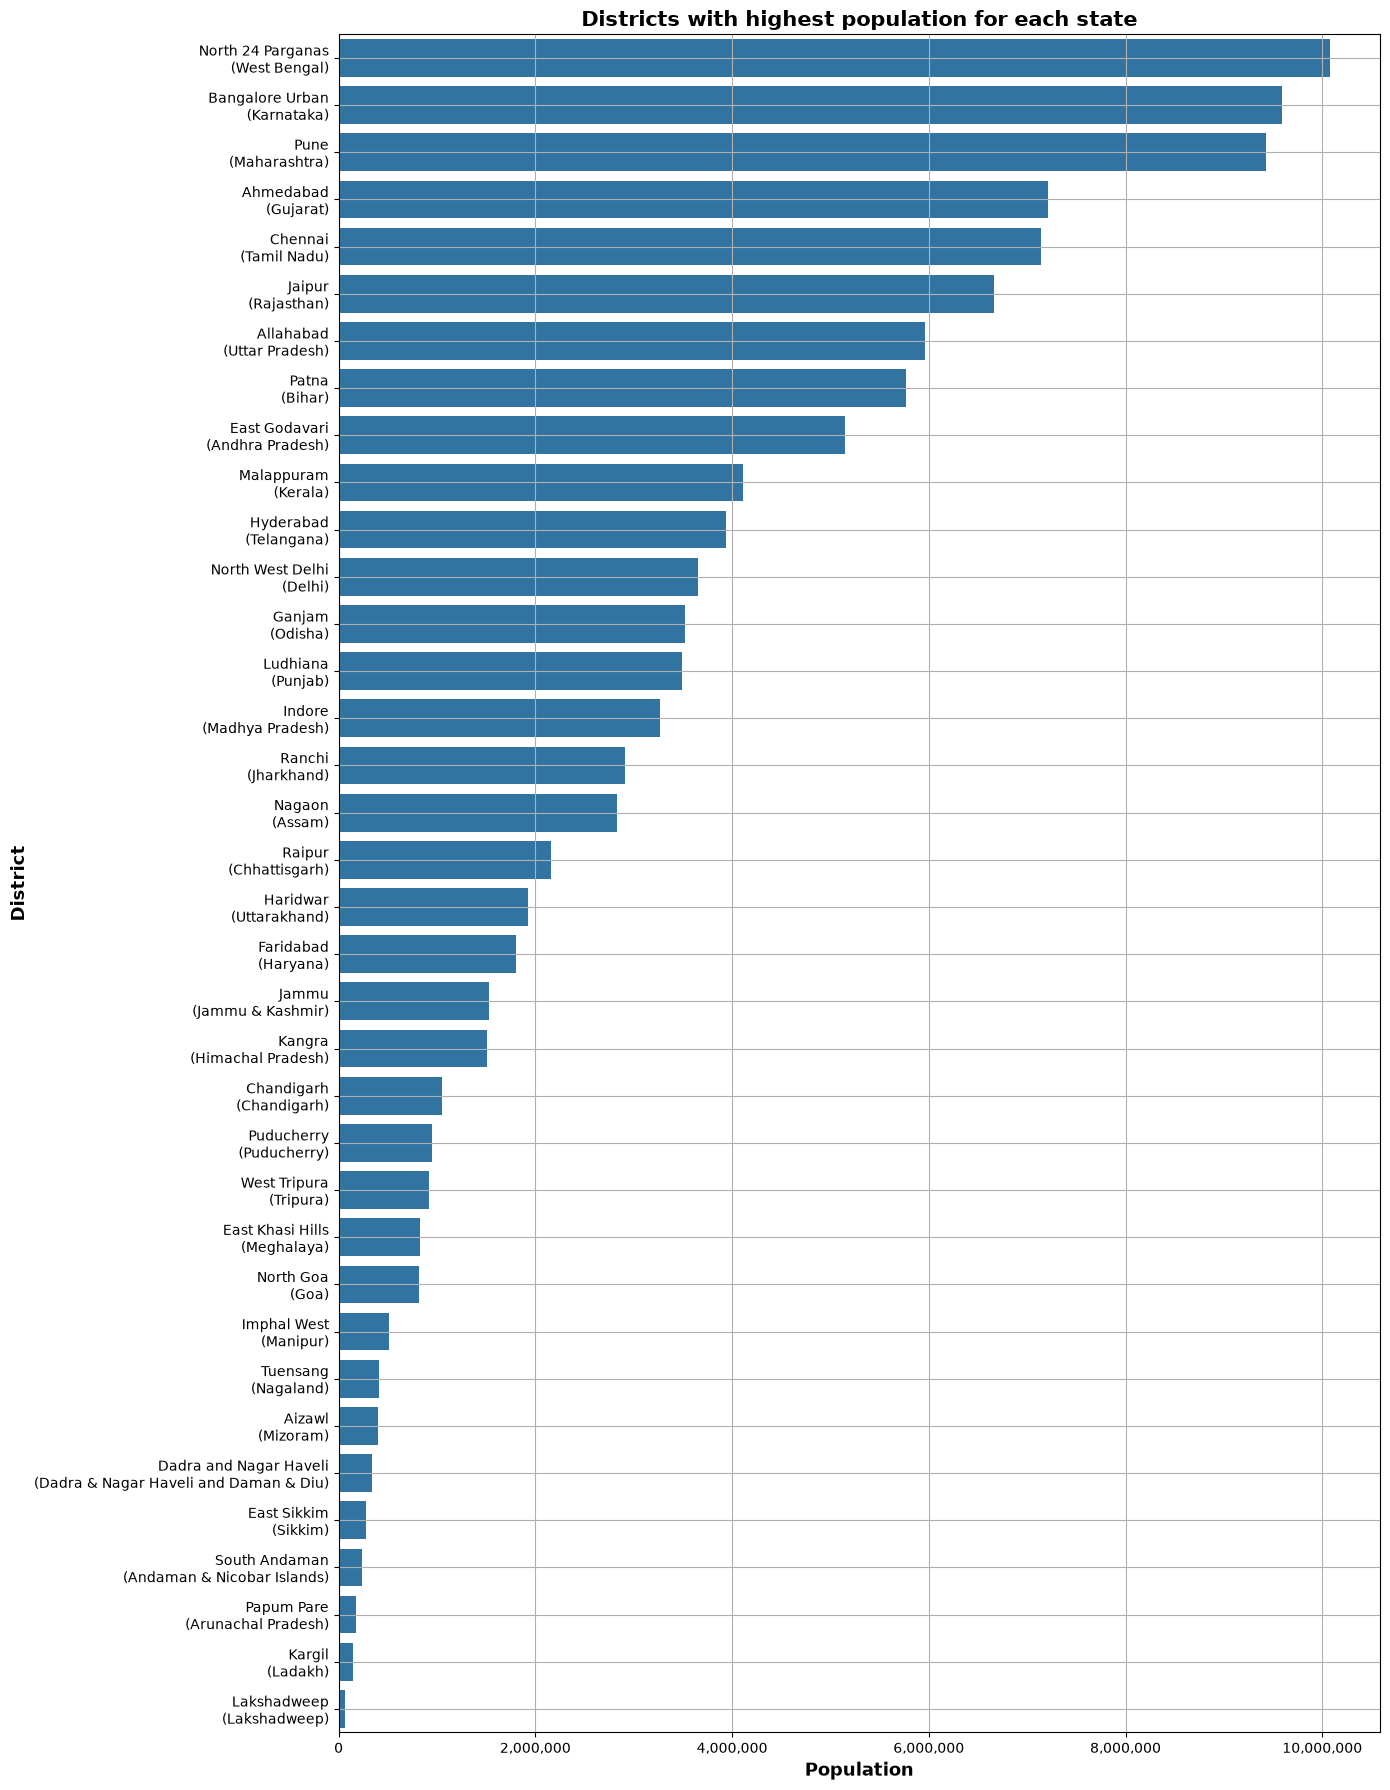

In [264]:
df_chart = df_district_highest_population.copy()
df_chart["Highest population district"] = (
    df_chart["Highest population district"] + "\n(" + df_chart["State"] + ")"
)

df_chart = df_chart.drop(columns="State")

df_chart = df_chart.sort_values(by="Population", ascending=False)

plt.figure(figsize=(14, 18))
sns.barplot(df_chart, x="Population", y="Highest population district")

plt.xlabel("Population", fontsize=13, fontweight="bold")
plt.ylabel("District", fontsize=13, fontweight="bold")
plt.title("Districts with highest population for each state", fontsize=15, fontweight="bold")

# show normal numbers on y axis not scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.tight_layout()
plt.show()